## Introduction and Problem Statement

The objective of this task is to predict whether a loan applicant is likely to default on a loan. This is a binary classification problem where the model classifies applicants into defaulters or non-defaulters.

We will perform data cleaning, exploratory data analysis (EDA), and train a machine learning model to make predictions.

## Dataset Understanding

The dataset contains information about loan applicants such as income, loan amount, education, and other financial attributes. The target variable indicates whether the applicant will default on the loan.

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [2]:
df = pd.read_csv('Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


**Dataset Understanding**

In [3]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

**Check Missing Values**

In [4]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

## Handling Missing Values

The dataset was checked for missing values using `.isnull().sum()`. No missing values were found, so no data imputation was required.

**EDA (Visualizations) Income Distribution**

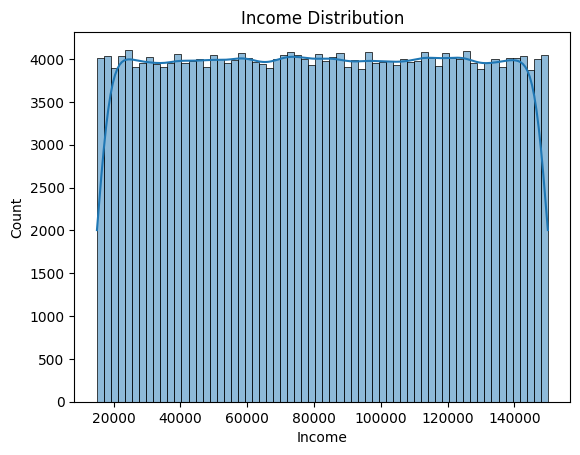

In [10]:
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

**Loan Amount Distribution**

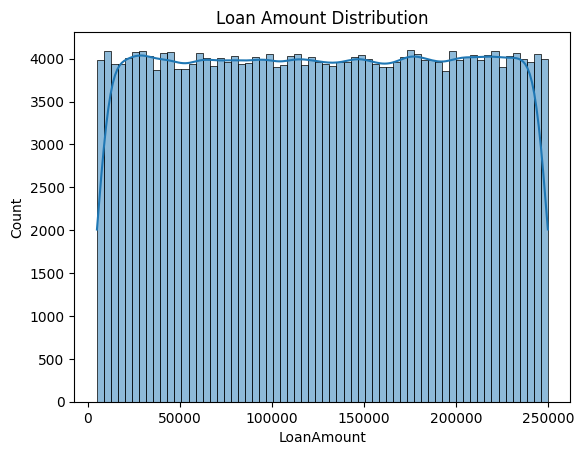

In [11]:
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

**Education vs Default**

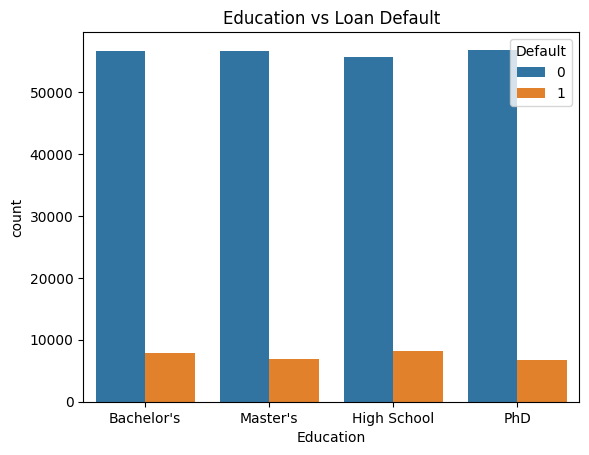

In [12]:
sns.countplot(x='Education', hue='Default', data=df)
plt.title("Education vs Loan Default")
plt.show()

**Credit Score vs Default**

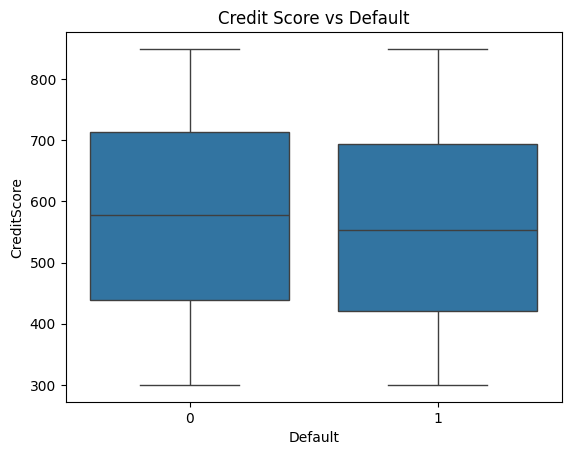

In [13]:
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title("Credit Score vs Default")
plt.show()

**Drop Unnecessary Column**

In [14]:
df = df.drop('LoanID', axis=1)

**Convert Categorical Data**

In [15]:
df = pd.get_dummies(df, drop_first=True)

**Define Features & Target**

In [16]:
X = df.drop('Default', axis=1)
y = df['Default']

**Train-Test Split**

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Model (Logistic Regression)**

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

**Predictions**

In [19]:
y_pred = model.predict(X_test)

**Evaluation (Accuracy)**

In [20]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.885275112590562


**Confusion Matrix**

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[45019   151]
 [ 5708   192]]


**Confusion Matrix Heatmap**

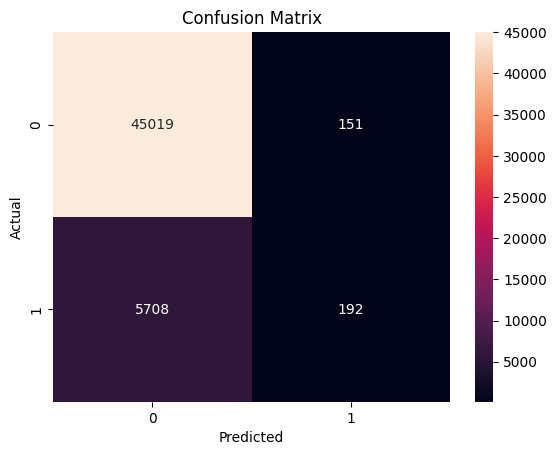

In [22]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Decision Tree (Accuracy)**

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8014881535147836


**Custom Input (Real Use Case)**

In [28]:
new_customer = X.iloc[0:1].copy()

new_customer['Income'] = 50000
new_customer['CreditScore'] = 700

prediction = model.predict(new_customer)
print(prediction)

[0]


## Conclusion

In this task, we analyzed a loan dataset to predict whether a customer is likely to default. The dataset was clean with no missing values.

Exploratory Data Analysis showed that features like income, loan amount, and credit score have a significant impact on loan default.

A Logistic Regression model was trained and evaluated using accuracy and confusion matrix. The model provides a good baseline for predicting credit risk.